# 图像编码 · 教师版 notebook

用于课前生成素材、课堂即时验证和课后拓展。

## 0. 运行位置检查

In [1]:

from pathlib import Path
lesson_dir = Path.cwd()
assets_dir = lesson_dir / "assets"
assert assets_dir.is_dir(), f"请从课程目录启动 notebook。当前目录：{lesson_dir}"
print("lesson directory:", lesson_dir)
print("assets directory:", assets_dir)


lesson directory: /Users/chran/repo/shtick/1-2-encoding/1-2-3-image-encoding
assets directory: /Users/chran/repo/shtick/1-2-encoding/1-2-3-image-encoding/assets


## Q1 / Q3 · 生成固定测试图

In [2]:

from pathlib import Path
from PIL import Image, ImageDraw

path = Path("assets/test-image.png")
path.parent.mkdir(parents=True, exist_ok=True)

w = h = 256
img = Image.new("RGB", (w, h))
px = img.load()
for y in range(h):
    for x in range(w):
        v = round(255 * x / (w - 1))
        px[x, y] = (v, v, v)

draw = ImageDraw.Draw(img)
draw.rectangle((12, 12, 72, 72), fill=(255, 0, 0))
draw.rectangle((73, 12, 133, 72), fill=(0, 255, 0))
draw.rectangle((184, 12, 244, 72), fill=(0, 0, 255))
draw.rectangle((0, 104, 128, 255), fill=(224, 224, 224))
draw.rectangle((136, 104, 255, 255), fill=(224, 224, 224))
draw.ellipse((0, 112, 128, 240), outline=(0, 0, 0), width=28)
draw.line((144, 240, 240, 144), fill=(0, 0, 0), width=28)
for x in [152, 160, 168, 176, 184, 192]:
    draw.line((x, 224, x, 244), fill=(255, 255, 255), width=2)

img.save(path)
assert img.size == (256, 256)
assert img.mode == "RGB"
print("created:", path)


created: assets/test-image.png


## Q2 · 生成同场景、同 4:3 构图的高像素模糊图与低像素清晰图

高像素图使用 `GaussianBlur(radius=12)`，用于模拟“高 pixel count 但图像质量受其他因素影响”。

In [3]:

from pathlib import Path
from PIL import Image, ImageDraw, ImageFilter

fallback_dir = Path("assets/fallback")
fallback_dir.mkdir(parents=True, exist_ok=True)

W, H = 1600, 1200
scene = Image.new("RGB", (W, H), (245, 246, 250))
d = ImageDraw.Draw(scene)
for y in range(H):
    shade = int(250 - 45 * y / (H - 1))
    d.line([(0, y), (W, y)], fill=(shade, shade, min(255, shade + 8)))

d.ellipse((170, 180, 730, 740), fill=(240, 244, 255), outline=(32, 32, 32), width=16)
d.line((280, 860, 1320, 320), fill=(10, 10, 10), width=24)
d.rectangle((920, 200, 1120, 400), fill=(255, 0, 0))
d.rectangle((1130, 200, 1330, 400), fill=(0, 180, 0))
d.rectangle((1340, 200, 1540, 400), fill=(0, 0, 255))
for x in range(970, 1510, 40):
    d.rectangle((x, 930, x + 10, 1060), fill=(35, 35, 35))

sharp800 = scene.resize((800, 600), Image.Resampling.LANCZOS)
blur1600 = scene.filter(ImageFilter.GaussianBlur(radius=12))

sharp800.save(fallback_dir / "q2-low-pixels-sharp.png")
blur1600.save(fallback_dir / "q2-high-pixels-blur.png")

print("Q2 high:", blur1600.size, "GaussianBlur radius=12")
print("Q2 low :", sharp800.size, "same 4:3 scene, no blur")


Q2 high: (1600, 1200) GaussianBlur radius=12
Q2 low : (800, 600) same 4:3 scene, no blur


## Q1 · Demo A · Sampling

预测：显示尺寸相同，降低 pixel dimensions 后，哪里最先变化？

课堂固定比较已经放入 PPTX；这里主要用于课前生成 fallback 和学生提出新尺寸时现场验证。

256 × 256


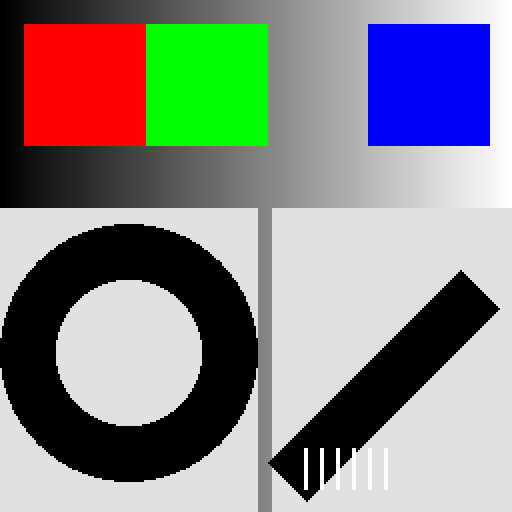

64 × 64


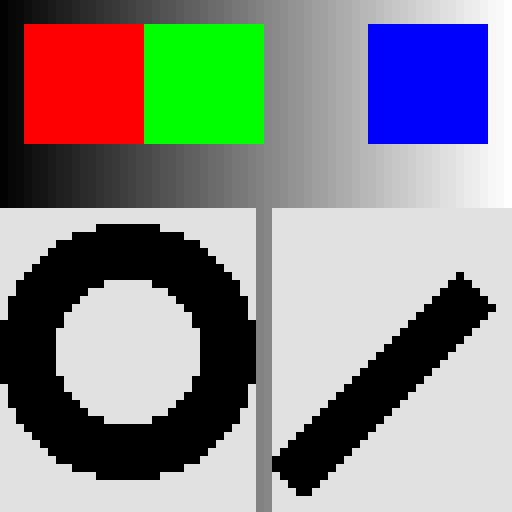

32 × 32


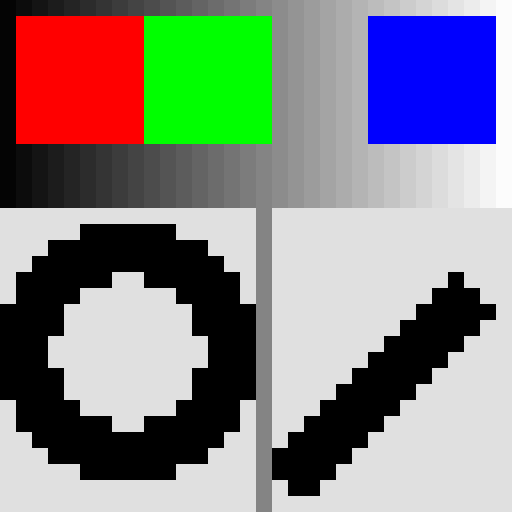

16 × 16


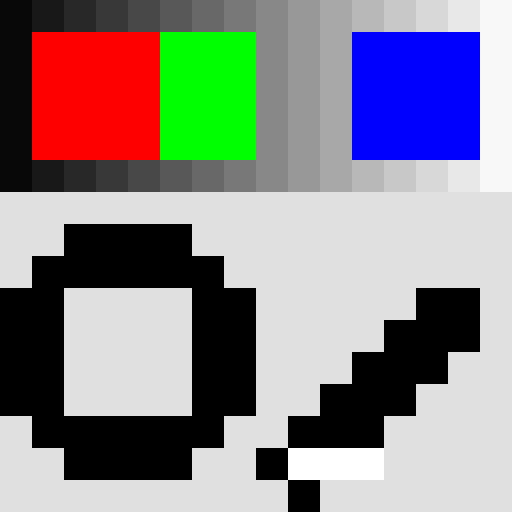

8 × 8


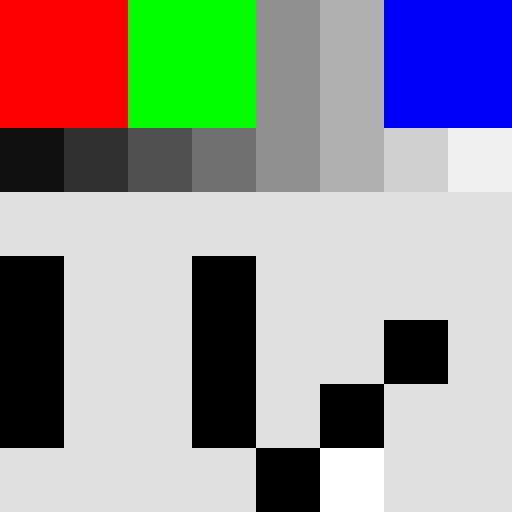

In [4]:

from pathlib import Path
from PIL import Image
from IPython.display import display

source_path = Path("assets/test-image.png")
src = Image.open(source_path).convert("RGB")
sizes = [256, 64, 32, 16, 8]
sampling_outputs = {}

for n in sizes:
    sampled = src.resize((n, n), resample=Image.Resampling.NEAREST)
    enlarged = sampled.resize((512, 512), resample=Image.Resampling.NEAREST)
    assert enlarged.mode == "RGB"
    assert enlarged.size == (512, 512)
    sampling_outputs[n] = enlarged
    print(f"{n} × {n}")
    display(enlarged)

def show_sampling(n: int):
    """课堂即时验证：输入学生提出的新尺寸。"""
    sampled = src.resize((n, n), resample=Image.Resampling.NEAREST)
    enlarged = sampled.resize((512, 512), resample=Image.Resampling.NEAREST)
    print(f"{n} × {n}")
    display(enlarged)
    return enlarged


## Q3 · Demo B · Quantization

先看图，不先打印接缝 RGB。

In [ ]:

from pathlib import Path
from PIL import Image
from IPython.display import display

source_path = Path("assets/test-image.png")
src = Image.open(source_path).convert("RGB")
targets = [256, 16, 4, 2]
main_targets = [16, 2]
outputs = {}

for n in targets:
    q = src.quantize(
        colors=n,
        method=Image.Quantize.MEDIANCUT,
        dither=Image.Dither.NONE,
    ).convert("RGB")
    colors = q.getcolors(maxcolors=n + 1)
    assert colors is not None
    color_count = len(colors)
    assert q.size == src.size
    assert q.mode == "RGB"
    assert color_count <= n
    outputs[n] = q

print("original")
display(src)
for n in main_targets:
    print(f"max {n} colors")
    display(outputs[n])


## Q3 · 接缝 RGB 证据

学生先观察图片后，再运行本格。

In [ ]:

seam_left = (72, 40)
seam_right = (73, 40)

for n in [16, 2]:
    left_rgb = outputs[n].getpixel(seam_left)
    right_rgb = outputs[n].getpixel(seam_right)
    print(
        f"{n:2d} colors | "
        f"left={left_rgb} | right={right_rgb} | "
        f"same={left_rgb == right_rgb}"
    )


## 导出 fallback 图片并复核

In [ ]:

from pathlib import Path
from PIL import Image

fallback_dir = Path("assets/fallback")
fallback_dir.mkdir(parents=True, exist_ok=True)

for n in [256, 64, 32, 16, 8]:
    img = sampling_outputs[n]
    assert img.mode == "RGB"
    assert img.size == (512, 512)
    img.save(fallback_dir / f"sampling-{n}.png")

quant_images = {"original": src, "16": outputs[16], "2": outputs[2]}
for label, img in quant_images.items():
    assert img.mode == "RGB"
    assert img.size == (256, 256)
    img.save(fallback_dir / f"quant-{label}.png")

# Re-open exported files and verify sizes + seam evidence.
for n in [256, 64, 32, 16, 8]:
    with Image.open(fallback_dir / f"sampling-{n}.png") as img:
        assert img.mode == "RGB"
        assert img.size == (512, 512)
for label in ["original", "16", "2"]:
    with Image.open(fallback_dir / f"quant-{label}.png") as img:
        assert img.mode == "RGB"
        assert img.size == (256, 256)
with Image.open(fallback_dir / "quant-16.png").convert("RGB") as q16:
    assert q16.getpixel(seam_left) != q16.getpixel(seam_right)
with Image.open(fallback_dir / "quant-2.png").convert("RGB") as q2:
    assert q2.getpixel(seam_left) == q2.getpixel(seam_right)
print("fallback verification passed", fallback_dir)


## Q6 · Demo C · RGB → bits

先让学生预测：`255` 和 `128` 的 8-bit binary 分别是什么？再运行代码核对。

In [ ]:

def to_8bit(n: int) -> str:
    return format(n, "08b")

rgb = (255, 128, 0)
print("RGB =", rgb)
print("R", rgb[0], "→", to_8bit(rgb[0]))
print("G", rgb[1], "→", to_8bit(rgb[1]))
print("B", rgb[2], "→", to_8bit(rgb[2]))
print("combined:", " ".join(to_8bit(v) for v in rgb))


## Q7 · BMP header 快速检查

In [ ]:

from pathlib import Path
import struct

path = Path("assets/q7-3x2-24bit.bmp")
data = path.read_bytes()
print("signature:", data[:2])
print("file bytes:", len(data))
print("pixel-data offset:", struct.unpack_from("<I", data, 10)[0])
print("bits per pixel:", struct.unpack_from("<H", data, 28)[0])
print("top red pixel bytes at 0x42:", data[66:69].hex(" "))


## 教师可选 · 将量化结果保存为 BMP 并检查 biBitCount

In [ ]:

from pathlib import Path
import struct

out_dir = Path("demo-output/quantization-bmp")
out_dir.mkdir(parents=True, exist_ok=True)

for n, q in outputs.items():
    bmp_path = out_dir / f"max-{n}-colors.bmp"
    q.save(bmp_path, format="BMP")
    data = bmp_path.read_bytes()
    bits_per_pixel = struct.unpack_from("<H", data, 28)[0]
    print(bmp_path.name, "| bpp =", bits_per_pixel, "| file bytes =", len(data))


## Q11 · Demo D · BMP row padding 拓展

In [ ]:

from pathlib import Path
import struct

path = Path("assets/q7-3x2-24bit.bmp")
data = path.read_bytes()
pixel_offset = struct.unpack_from("<I", data, 10)[0]
width = struct.unpack_from("<i", data, 18)[0]
height = struct.unpack_from("<i", data, 22)[0]
bits_per_pixel = struct.unpack_from("<H", data, 28)[0]
rows = abs(height)
color_value_bytes = width * rows * bits_per_pixel // 8
row_value_bytes = width * bits_per_pixel // 8
stored_row_bytes = ((width * bits_per_pixel + 31) // 32) * 4
pixel_array_bytes = stored_row_bytes * rows
file_bytes = len(data)
print("pixel-data offset :", pixel_offset, "bytes")
print("color values      :", color_value_bytes, "bytes")
print("raw row values    :", row_value_bytes, "bytes/row")
print("stored row size   :", stored_row_bytes, "bytes/row")
print("pixel array       :", pixel_array_bytes, "bytes")
print("whole file        :", file_bytes, "bytes")
